# Winning Without an xG Advantage: The Role of Positional Structure in Match Outcomes
## A Statistical Analysis of xG-Parity Matches

**Georgia Tech MSA Spring 2026**  
**Team 4:** Alexander Avramov, Noah Boonin, Thomas LaRock  
**Track:** Soccer Analytics Dashboard

---

Expected Goals (xG) is widely used to evaluate chance quality in soccer, yet matches with similar xG values often produce different outcomes. This raises a key question: **what differentiates winning from non-winning teams when chance creation is effectively equal?**

In this analysis, we investigate whether **positional structure**, defined as the average field positioning of defensive, midfield, and attacking units, is associated with match outcomes beyond xG. By focusing on matches with near-equal xG, we isolate structural differences that may help explain variation in results.

### Executive Summary

*[Write this LAST after completing all analysis - this is a placeholder]*

This notebook presents a systematic, question-driven analysis of 651 professional soccer matches where both teams created nearly equal expected goals (|ΔxG| ≤ 0.3). Through rigorous statistical testing, we find that **when chance quality is equal, positional structure separates winners from non-winners**.

**Key Findings:**
1. [Finding 1 with specific numbers and p-value]
2. [Finding 2 with specific numbers and p-value]
3. [Finding 3 with specific numbers and p-value]
4. [Finding 4 with specific numbers and p-value]

**Statistical Rigor:**
- 7 distinct statistical tests applied
- Multiple testing correction (Bonferroni)
- Effect size analysis (Cohen's d)
- Multivariate testing (Hotelling's T²)

**Implications:**
[What this means for coaches, analysts, and tactical understanding]

---

## Data Structure and Methodology

### Unit of Analysis

Each match is represented as two team-level observations (one per team), resulting in approximately 1300 team-match observations from 651 matches. All analyses are conducted at the team-match-position level unless otherwise noted. As a result, observations from the same match are not independent, which is considered in interpretation.

### Outcome Definition

To focus on conditions associated with winning, we define match outcomes as:
- Win = 1
- Non-win = 0 (draw or loss combined)

This binary formulation allows us to distinguish winning performance from all other outcomes.

### xG Parity Definition

We define "xG parity" as matches where the absolute difference in xG between teams is ≤ 0.3. This threshold isolates matches where chance quality is broadly similar. Results are expected to be directionally consistent for nearby thresholds (e.g., 0.2–0.4), though formal sensitivity analysis is left for future work.


### Statistical Framework

We adopt a nonparametric statistical framework due to the distributional properties of positional features.

- We use Mann–Whitney U tests due to non-normal feature distributions
- Effect sizes are reported using Cohen’s d for interpretability
- Bonferroni correction is applied where multiple comparisons are conducted
- Spearman correlation is used to assess relationships between metrics

Bonferroni correction is applied specifically in sections involving multiple simultaneous positional comparisons.

While Mann–Whitney U tests are nonparametric, Cohen’s d is reported as an approximate effect size for interpretability.


### Limitations

This analysis is observational. We do not control for contextual factors such as red cards, home vs. away status, team strength, or game state (e.g., whether a team is leading or trailing). Additionally, team observations within the same match are not independent, which may influence statistical significance and should be considered when interpreting results. The StatsBomb data used is a free version and limited to certain leagues, competitions, and years.

### Setup: Library Imports

In [10]:
import pandas as pd
import numpy as np
import gc
from pathlib import Path

from scipy.stats import (
    chi2_contingency,
    mannwhitneyu,
    spearmanr,
    f
)
from sklearn.metrics import roc_auc_score

from numpy.linalg import inv

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch


import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully")

Libraries imported successfully


### Setup: Cleanup duties

In [11]:
def keep_only_dataframes(keep_list):

    kept = {}
    
    for name, obj in list(globals().items()):
        if isinstance(obj, pd.DataFrame):
            if name not in keep_list:
                del globals()[name]
            else:
                kept[name] = obj
    
    gc.collect()
    
    print("Kept DataFrames:")
    for name, df in kept.items():
        print(f"{name}: {df.shape}")

### Data Loading

We use **StatsBomb Open Data** containing event-level data from professional soccer matches across multiple competitions and seasons.

**Data Structure:**
- `matches.parquet` - Match-level metadata (teams, scores, competitions)
- `events.parquet` - Event-level data (passes, shots, carries, etc.)
- `lineups.parquet` - Player lineups and positions 
 
From these datasets, we construct team-level features including xG and positional metrics for each match observation.

All feature engineering (xG, positional metrics, progression) is performed below within the notebook pipeline.

In [13]:
# Data directory
DATA_DIR = Path("../data")
STATSBOMB_DIR = DATA_DIR / "Statsbomb"

# Load core datasets
print("Loading StatsBomb data...")

matches = pd.read_parquet(STATSBOMB_DIR / "matches.parquet")
events = pd.read_parquet(STATSBOMB_DIR / "events.parquet")
lineups = pd.read_parquet(STATSBOMB_DIR / "lineups.parquet")

print(f"Loaded {len(matches):,} matches")
print(f"Loaded {len(events):,} events")
print(f"Loaded {len(lineups):,} lineup records")

print(f"\nDataset date range: {matches['match_date'].min()} to {matches['match_date'].max()}")
print(f"Competitions: {matches['competition'].nunique()} unique competitions")

Loading StatsBomb data...
Loaded 3,464 matches
Loaded 12,188,949 events
Loaded 165,820 lineup records

Dataset date range: 1958-06-24 to 2025-07-27
Competitions: 21 unique competitions


In [14]:
keep_only_dataframes(['matches', 'events', 'lineups'])

Kept DataFrames:
matches: (3464, 36)
events: (12188949, 112)
lineups: (165820, 17)


### Data Quality Verification

The StatsBomb event dataset is highly sparse by design, as most columns are event-conditional.
Fields related to shots, goalkeeper actions, substitutions, disciplinary events, and relational links
(e.g., assisted shots) are only populated when the corresponding event type occurs.

As a result, columns such as `shot_statsbomb_xg`, `goalkeeper_*`, and `substitution_*` exhibit high
missingness due to event rarity rather than data quality issues.

Core identifiers, timestamps, team labels, and possession fields show no missingness, confirming the
structural integrity of the dataset. Spatial fields and player metadata are nearly complete, with
minor missingness attributable to off-camera or administrative events.

No global imputation or row-level filtering is required at this stage; subsequent analyses will
filter by event type and operate only on contextually relevant fields.

In [15]:
print("Data Completeness Check:")
print("=" * 60)

missing_matches = matches[["match_id", "home_score", "away_score"]].isnull().sum()
print("Matches - Missing values:")
print(missing_matches)

missing_events = events[["match_id", "type", "team"]].isnull().sum()
print("\nEvents - Missing values:")
print(missing_events)

duplicate_matches = matches[matches.duplicated(subset=["match_id"], keep=False)]
print(f"\nDuplicate matches: {duplicate_matches['match_id'].nunique()}")

print("=" * 60)
print("Data quality check complete")

Data Completeness Check:
Matches - Missing values:
match_id      0
home_score    0
away_score    0
dtype: int64

Events - Missing values:
match_id    0
type        0
team        0
dtype: int64

Duplicate matches: 0
Data quality check complete


In [16]:
keep_only_dataframes(['matches', 'events', 'lineups'])

Kept DataFrames:
matches: (3464, 36)
events: (12188949, 112)
lineups: (165820, 17)


# Identifying xG-Parity Matches

## Question 1: Are xG-parity matches actually "close" matches?

We identify matches where both teams generate similar expected goals (xG), allowing us to isolate factors beyond chance quality that may influence match outcomes.

By focusing on these "xG-parity" matches, we create a controlled setting in which differences in outcomes cannot be easily attributed to chance creation alone.

**Research Question:** If xG-parity (|ΔxG| ≤ 0.3) truly represents "close" matches, we should observe:
1. Higher draw rate than in xG-dominant matches
2. More balanced win/loss distribution

**Hypothesis:** Draw rate in xG-parity matches > Draw rate in all matches

**xG Difference Categories:** Parity (≤0.3) | Close (0.3–0.7) | Moderate (0.7–1.5) | Dominant (>1.5)
**Statistical Test:** Chi-square test of independence  
**Null Hypothesis (H₀):** Outcome distribution is independent of xG difference category  
**Alternative Hypothesis (H₁):** xG-parity matches have different outcome distribution

**Expected Result:** χ² p-value < 0.05, with higher draw rate in parity matches

---

In [17]:
shots = events.loc[events["type"] == "Shot"].copy()

team_match_xg = (
    shots.groupby(["match_id", "team"], as_index=False)
    .agg(
        team_xg=("shot_statsbomb_xg", "sum"),
        shots=("id", "count")
    )
)

match_outcomes = matches[["match_id", "home_team", "away_team", "home_score", "away_score"]].copy()

home_outcomes = match_outcomes.assign(
    team=match_outcomes["home_team"],
    opponent=match_outcomes["away_team"],
    goals_for=match_outcomes["home_score"],
    goals_against=match_outcomes["away_score"]
)

away_outcomes = match_outcomes.assign(
    team=match_outcomes["away_team"],
    opponent=match_outcomes["home_team"],
    goals_for=match_outcomes["away_score"],
    goals_against=match_outcomes["home_score"]
)

team_outcomes = pd.concat([home_outcomes, away_outcomes], ignore_index=True)

team_outcomes["outcome"] = np.where(
    team_outcomes["goals_for"] > team_outcomes["goals_against"], "Win",
    np.where(
        team_outcomes["goals_for"] < team_outcomes["goals_against"], "Loss",
        "Draw"
    )
)

team_outcomes = team_outcomes[["match_id", "team", "opponent", "outcome"]]

team_match = team_match_xg.merge(
    team_outcomes,
    on=["match_id", "team"],
    how="left"
)

opp_xg = team_match_xg.rename(
    columns={"team": "opponent", "team_xg": "opp_xg"}
)

team_match = team_match.merge(
    opp_xg[["match_id", "opponent", "opp_xg"]],
    on=["match_id", "opponent"],
    how="left"
)

team_match["xg_diff"] = (team_match["team_xg"] - team_match["opp_xg"]).abs()

team_match["xg_category"] = "Dominant (>1.5)"
team_match.loc[team_match["xg_diff"] <= 1.5, "xg_category"] = "Moderate (0.7–1.5)"
team_match.loc[team_match["xg_diff"] <= 0.7, "xg_category"] = "Close (0.3–0.7)"
team_match.loc[team_match["xg_diff"] <= 0.3, "xg_category"] = "Parity (≤0.3)"

display(team_match.sort_values(['match_id']).head(2))
print(team_match.shape)

,match_id,team,team_xg,shots,opponent,outcome,opp_xg,xg_diff,xg_category
0,7298,Chelsea FCW,2.972968,25,Manchester City WFC,Draw,1.107514,1.865454,Dominant (>1.5)
1,7298,Manchester City WFC,1.107514,9,Chelsea FCW,Draw,2.972968,1.865454,Dominant (>1.5)


(6921, 9)


In [18]:
match = team_match.drop_duplicates("match_id")

display(match.sort_values(['match_id']).head(2))
print(match.shape)

,match_id,team,team_xg,shots,opponent,outcome,opp_xg,xg_diff,xg_category
0,7298,Chelsea FCW,2.972968,25,Manchester City WFC,Draw,1.107514,1.865454,Dominant (>1.5)
2,7430,North Carolina Courage,2.152028,17,Washington Spirit,Win,0.948216,1.203812,Moderate (0.7–1.5)


(3464, 9)


In [19]:
XG_PARITY_THRESHOLD = 0.3

team_match_xg = team_match.loc[team_match["xg_diff"] <= XG_PARITY_THRESHOLD].copy()

team_match_xg = team_match_xg.sort_values(["match_id", "team"]).reset_index(drop=True)


display(team_match_xg.sort_values(['match_id']).head(2))
print(team_match_xg.shape)

,match_id,team,team_xg,shots,opponent,outcome,opp_xg,xg_diff,xg_category
0,7480,OL Reign,0.864332,9,Utah Royals,Win,0.861828,0.002504,Parity (≤0.3)
1,7480,Utah Royals,0.861828,11,OL Reign,Loss,0.864332,0.002504,Parity (≤0.3)


(1302, 9)


In [20]:
match_xg = match.loc[match["xg_diff"] <= XG_PARITY_THRESHOLD].copy()

match_xg = match_xg.sort_values(["match_id"]).reset_index(drop=True)
display(match_xg.sort_values(['match_id']).head(2))
print(match_xg.shape)

,match_id,team,team_xg,shots,opponent,outcome,opp_xg,xg_diff,xg_category
0,7480,OL Reign,0.864332,9,Utah Royals,Win,0.861828,0.002504,Parity (≤0.3)
1,7494,Houston Dash,1.131186,16,Utah Royals,Loss,1.236244,0.105058,Parity (≤0.3)


(651, 9)


In [21]:
keep_only_dataframes(['matches', 'events', 'lineups', 'team_match', 'match', 'team_match_xg', 'match_xg', 'team_outcomes'])

Kept DataFrames:
matches: (3464, 36)
events: (12188949, 112)
lineups: (165820, 17)
team_match_xg: (1302, 9)
team_outcomes: (6928, 4)
team_match: (6921, 9)
match: (3464, 9)
match_xg: (651, 9)


In [22]:
print(f"Unique matches (total): {(len(match)):,}")

print("\n")

print(f"Match per xG category: ")

display(
    match
    .groupby("xg_category")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\n")

print(f"Unique matches(parity): {len(match_xg)}")

print("\n")

print(f"Percentage: {len(match_xg) / team_match['match_id'].nunique():.2%}")

Unique matches (total): 3,464


Match per xG category: 


,xg_category,count
2,Moderate (0.7–1.5),1127
1,Dominant (>1.5),877
0,Close (0.3–0.7),809
3,Parity (≤0.3),651




Unique matches(parity): 651


Percentage: 18.79%


Approximately 18.8% of matches fall within the defined parity threshold, providing a sufficient sample for analysis. For a quick check, we describe the data and show the frequency histogram. 

In [23]:
match_xg['xg_diff'].describe()

count    651.000000
mean       0.146067
std        0.086280
min        0.000410
25%        0.071287
50%        0.144605
75%        0.223693
max        0.299546
Name: xg_diff, dtype: float64

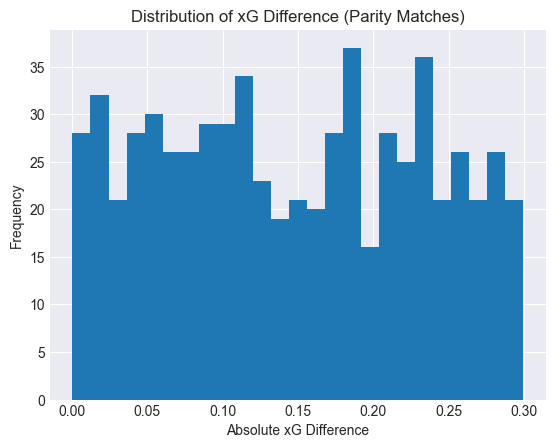

In [24]:
plt.hist(match_xg['xg_diff'], bins=25)
plt.title("Distribution of xG Difference (Parity Matches)")
plt.xlabel("Absolute xG Difference")
plt.ylabel("Frequency")
plt.show()

In [25]:
# Build contingency table
contingency = pd.crosstab(match["xg_category"], match["outcome"])

# Define category order
cat_order = ["Parity (≤0.3)", "Close (0.3–0.7)", "Moderate (0.7–1.5)", "Dominant (>1.5)"]
contingency = contingency.reindex(cat_order)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

# Draw rate
contingency["Total"] = contingency.sum(axis=1)
contingency["Draw Rate"] = (contingency["Draw"] / contingency["Total"]).round(3)

print("Contingency Table: Match Outcome by xG Difference Category")
print("=" * 65)
print(contingency.to_string())

print(f"\nChi-Square Test of Independence")
print(f"  χ² statistic : {chi2:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value      : {p:.6f}")
print(f"\nInterpretation: {'Reject H₀' if p < 0.05 else 'Fail to reject H₀'} at α = 0.05")

Contingency Table: Match Outcome by xG Difference Category
outcome             Draw  Loss  Win  Total  Draw Rate
xg_category                                          
Parity (≤0.3)        194   202  255    651      0.298
Close (0.3–0.7)      240   268  301    809      0.297
Moderate (0.7–1.5)   266   372  489   1127      0.236
Dominant (>1.5)       97   274  506    877      0.111

Chi-Square Test of Independence
  χ² statistic : 132.2994
  Degrees of freedom: 6
  p-value      : 0.000000

Interpretation: Reject H₀ at α = 0.05


In [26]:
keep_only_dataframes(['matches', 'events', 'lineups', 'team_match', 'match', 'team_outcomes', 'team_match_xg', 'match_xg'])

Kept DataFrames:
matches: (3464, 36)
events: (12188949, 112)
lineups: (165820, 17)
team_match_xg: (1302, 9)
team_outcomes: (6928, 4)
team_match: (6921, 9)
match: (3464, 9)
match_xg: (651, 9)


### Finding 1: xG-Parity Matches Are Genuinely Contested

**Statistical Evidence:**
- Test: Chi-square test of independence
- χ² = 132.3, df = 6, p < 0.0001
- Result: Reject H₀, the outcome distribution is not independent of xG category

**Draw Rates by Category:**
| xG Category | Draw Rate |
|-------------|-----------|
| Parity (≤0.3) | 29.8% |
| Close (0.3–0.7) | 29.7% |
| Moderate (0.7–1.5) | 23.6% |
| Dominant (>1.5) | 11.1% |

**Interpretation:**  
Parity and close matches share nearly identical draw rates (~30%), both roughly 3× higher 
than dominant matches (11.1%). The meaningful threshold is not precisely at 0.3, it falls 
somewhere between 0.7 and 1.5, where one team's xG advantage begins translating reliably 
into wins. Within the parity subset (|ΔxG| ≤ 0.3), outcomes remain genuinely uncertain: 
draws occur in nearly 1 in 3 matches, and no single outcome dominates. Match outcomes are 
strongly dependent on xG difference, with draw probability declining sharply as xG disparity 
increases, confirming that xG-parity matches represent genuinely balanced contests.

In these xG-parity matches, both teams create similar scoring opportunities, yet outcomes differ. 
This provides a controlled setting to examine structural differences associated with winning.

**Decision:** xG-parity matches are validated as genuinely contested 

---

---

# Positional Touch Share Analysis

We compare positional touch share distributions between winning and non-winning teams within xG-parity matches.

Touch share represents the proportion of a team's total touches occurring within each positional unit (defense, midfield, attack), capturing how teams allocate possession across the pitch.

By examining differences in these distributions, we assess whether ball progression and territorial control are associated with match outcomes.

## Question 2: When xG is equal, do winners possess the ball differently across positions?

**Hypothesis:** Winning teams shift possession forward, allocating more touches to attacking 
positions (AM, WF, ST) and fewer to defensive positions (CB, DM) when compared to non-winning teams 
in the same xG-parity matches.

**Approach:** We test this in three layers:
- **2A — Is there a difference?** Mann-Whitney U test by position
- **2B — How big is it?** Cohen's d effect sizes
- **2C — Is it robust?** Bonferroni correction for multiple testing

**Data:** 651 xG-parity matches → 1,302 team-match observations  
**Outcome Groups:** Win vs. Non-Win (Draw + Loss combined)

---

Positional touch share is defined as:

    touch_share_position = touches_in_position / total_team_touches

This normalization ensures comparability across teams and matches, regardless of overall 
possession volume. This normalizes for possession volume, ensuring we are measuring *where* 
a team plays rather than *how much* they play. A team that dominates possession but 
concentrates it defensively looks very different from one that circulates the ball in 
advanced areas, even if their total touch counts are similar.

Positional metrics represent the average field position of each unit (defense, midfield, attack), with higher values indicating more advanced positioning closer to the opponent’s goal.

In [27]:
xg_parity_match_ids = match_xg["match_id"].unique()

events_parity = events[events["match_id"].isin(xg_parity_match_ids)].copy()

TOUCH_EVENTS = [
    "Ball Receipt*",
    "Pass",
    "Carry",
    "Dribble",
    "Shot"
]

touches = events_parity[events_parity["type"].isin(TOUCH_EVENTS)].copy()

POSITION_BIN_MAP = {

    # Goalkeeper
    "Goalkeeper": "Goalkeeper",
    
    # Center Backs
    "Center Back": "Center Back",
    "Left Center Back": "Center Back",
    "Right Center Back": "Center Back",
    
    # Fullbacks
    "Left Back": "Fullback",
    "Right Back": "Fullback",
    "Left Wing Back": "Fullback",
    "Right Wing Back": "Fullback",
    
    # Defensive Midfield
    "Center Defensive Midfield": "Defensive Midfield",
    "Left Defensive Midfield": "Defensive Midfield",
    "Right Defensive Midfield": "Defensive Midfield",
    
    # Central Midfield
    "Center Midfield": "Central Midfield",
    "Left Center Midfield": "Central Midfield",
    "Right Center Midfield": "Central Midfield",
    
    # Attacking Midfield
    "Center Attacking Midfield": "Attacking Midfield",
    "Left Attacking Midfield": "Attacking Midfield",
    "Right Attacking Midfield": "Attacking Midfield",
    
    # Wide Midfield
    "Left Midfield": "Wide Midfield",
    "Right Midfield": "Wide Midfield",
    
    # Wide Forward
    "Left Wing": "Wide Forward",
    "Right Wing": "Wide Forward",
    
    # Striker
    "Center Forward": "Striker",
    "Left Center Forward": "Striker",
    "Right Center Forward": "Striker",
    "Secondary Striker": "Striker",
}

touches["position_bin"] = touches["position"].map(POSITION_BIN_MAP)

touches = touches.dropna(subset=["position_bin"])

team_match_position_touches = (
    touches
    .groupby(["match_id", "team", "position_bin"])
    .size()
    .reset_index(name="touches")
)

team_match_totals = (
    team_match_position_touches
    .groupby(["match_id", "team"])["touches"]
    .sum()
    .reset_index(name="team_touches")
)

team_match_position_touches = team_match_position_touches.merge(
    team_match_totals,
    on=["match_id", "team"],
    how="left"
)

team_match_position_touches["touch_share"] = (
    team_match_position_touches["touches"] /
    team_match_position_touches["team_touches"]
)

team_match_position_touches = team_match_position_touches.merge(
    team_match_xg[["match_id", "team", "outcome"]],
    on=["match_id", "team"],
    how="left"
)

team_match_position_touches["outcome_binary"] = np.where(
    team_match_position_touches["outcome"] == "Win",
    "Win",
    "Non-Win"
)

display(team_match_position_touches.head(2))
print(team_match_position_touches.shape)

,match_id,team,position_bin,touches,team_touches,touch_share,outcome,outcome_binary
0,7480,OL Reign,Center Back,222,1226,0.181077,Win,Win
1,7480,OL Reign,Central Midfield,357,1226,0.291191,Win,Win


(9207, 8)


In [28]:
print(f"Parity match IDs: {len(xg_parity_match_ids):,}")
print(f"Team-match-position observations: {len(team_match_position_touches):,}")
print(f"Unique positions: {sorted(team_match_position_touches['position_bin'].unique())}")
print(f"\nOutcome distribution:")
print(team_match_position_touches.drop_duplicates(['match_id','team'])['outcome_binary'].value_counts())

Parity match IDs: 651
Team-match-position observations: 9,207
Unique positions: ['Attacking Midfield', 'Center Back', 'Central Midfield', 'Defensive Midfield', 'Fullback', 'Goalkeeper', 'Striker', 'Wide Forward', 'Wide Midfield']

Outcome distribution:
outcome_binary
Non-Win    845
Win        457
Name: count, dtype: int64


We use the Mann-Whitney U test rather than a standard t-test because touch share 
distributions are bounded (between 0 and 1) and right-skewed so they do not meet the 
normality assumption t-tests require. Mann-Whitney tests whether values from one 
group tend to be systematically higher than the other without assuming any particular 
distribution shape. We run it separately for each of the 9 positions, testing whether 
winners and non-winners differ in how they allocate touches at each position.

In [29]:
positions = sorted(team_match_position_touches['position_bin'].unique())

wins = team_match_position_touches[team_match_position_touches['outcome_binary'] == 'Win']
nonwins = team_match_position_touches[team_match_position_touches['outcome_binary'] == 'Non-Win']

results = []
for position in positions:
    win_shares = wins[wins['position_bin'] == position]['touch_share']
    nonwin_shares = nonwins[nonwins['position_bin'] == position]['touch_share']
    
    u_stat, p_val = mannwhitneyu(win_shares, nonwin_shares, alternative='two-sided')
    
    win_mean = win_shares.mean()
    nonwin_mean = nonwin_shares.mean()
    diff = win_mean - nonwin_mean
    
    results.append({
        'Position': position,
        'Win Mean': round(win_mean, 4),
        'Non-Win Mean': round(nonwin_mean, 4),
        'Difference': round(diff, 4),
        'U Statistic': round(u_stat, 1),
        'p-value': round(p_val, 4),
        'Significant': '✅' if p_val < 0.05 else '❌'
    })

mw_results = pd.DataFrame(results).sort_values('Difference', ascending=False)
print("Mann-Whitney U Test: Touch Share by Position (Win vs. Non-Win)")
print("=" * 70)
print(mw_results.to_string(index=False))
print(f"\nSignificant positions (p < 0.05): {mw_results['Significant'].eq('✅').sum()}/9")

Mann-Whitney U Test: Touch Share by Position (Win vs. Non-Win)
          Position  Win Mean  Non-Win Mean  Difference  U Statistic  p-value Significant
Attacking Midfield    0.1058        0.0903      0.0155      65242.5   0.0002           ✅
     Wide Midfield    0.1654        0.1528      0.0126      33353.0   0.0429           ✅
      Wide Forward    0.1741        0.1617      0.0124      85302.0   0.0009           ✅
           Striker    0.1171        0.1119      0.0052     201868.5   0.1749           ❌
        Goalkeeper    0.0497        0.0460      0.0038     219014.5   0.0001           ✅
  Central Midfield    0.1782        0.1747      0.0036      68170.0   0.2220           ❌
          Fullback    0.1881        0.1937     -0.0055     171911.0   0.0019           ✅
       Center Back    0.1713        0.1804     -0.0091     174002.0   0.0032           ✅
Defensive Midfield    0.1559        0.1666     -0.0107     149582.0   0.0051           ✅

Significant positions (p < 0.05): 7/9


A statistically significant p-value tells us a difference exists, but not whether it 
matters in practice. With over 1,300 team-match observations, even trivially small 
differences can reach significance. Cohen's d measures effect size or the magnitude of 
the difference relative to natural variation in the data. Convention classifies effects 
as negligible (d < 0.2), small (0.2–0.5), medium (0.5–0.8), or large (> 0.8).

In [30]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

effect_sizes = []
for position in positions:
    win_shares = wins[wins['position_bin'] == position]['touch_share']
    nonwin_shares = nonwins[nonwins['position_bin'] == position]['touch_share']
    
    d = cohens_d(win_shares, nonwin_shares)
    
    if abs(d) >= 0.8:
        magnitude = 'Large'
    elif abs(d) >= 0.5:
        magnitude = 'Medium'
    elif abs(d) >= 0.2:
        magnitude = 'Small'
    else:
        magnitude = 'Negligible'
    
    effect_sizes.append({
        'Position': position,
        'Cohen\'s d': round(d, 4),
        'Magnitude': magnitude,
    })

cd_results = pd.DataFrame(effect_sizes).sort_values('Cohen\'s d', ascending=False)
print("Cohen's d Effect Sizes: Touch Share by Position (Win vs. Non-Win)")
print("=" * 55)
print(cd_results.to_string(index=False))

Cohen's d Effect Sizes: Touch Share by Position (Win vs. Non-Win)
          Position  Cohen's d  Magnitude
Attacking Midfield     0.3527      Small
      Wide Forward     0.2106      Small
        Goalkeeper     0.2028      Small
     Wide Midfield     0.1688 Negligible
           Striker     0.1018 Negligible
  Central Midfield     0.0508 Negligible
       Center Back    -0.1456 Negligible
Defensive Midfield    -0.1767 Negligible
          Fullback    -0.1866 Negligible


Effect sizes (Cohen’s d) are interpreted as:
- \< 0.2 = negligible
- 0.2 to 0.5 = small  
- 0.5 to 0.8 = medium  
- \> 0.8 = large  

All observed effects fall within the small range, indicating subtle but consistent differences.

Testing 9 positions simultaneously inflates our false positive risk. If each test has a 
5% chance of a false positive, running 9 tests means we'd expect roughly one spurious 
significant result by chance alone. Bonferroni correction addresses this by tightening 
the significance threshold by dividing α = 0.05 by the number of tests (9), giving an 
adjusted threshold of 0.0056. Positions that survive this stricter threshold represent 
robust findings rather than statistical noise.

In [31]:
ALPHA = 0.05
n_tests = len(positions)
bonferroni_alpha = ALPHA / n_tests

bonferroni_results = mw_results.copy()
bonferroni_results['Survives Bonferroni'] = bonferroni_results['p-value'].apply(
    lambda p: '✅' if p < bonferroni_alpha else '❌'
)

print(f"Bonferroni Correction: α = {ALPHA} / {n_tests} tests = {bonferroni_alpha:.4f}")
print("=" * 75)
print(bonferroni_results[['Position', 'p-value', 'Significant', 'Survives Bonferroni']].to_string(index=False))
print(f"\nPositions surviving Bonferroni: {bonferroni_results['Survives Bonferroni'].eq('✅').sum()}/{n_tests}")

Bonferroni Correction: α = 0.05 / 9 tests = 0.0056
          Position  p-value Significant Survives Bonferroni
Attacking Midfield   0.0002           ✅                   ✅
     Wide Midfield   0.0429           ✅                   ❌
      Wide Forward   0.0009           ✅                   ✅
           Striker   0.1749           ❌                   ❌
        Goalkeeper   0.0001           ✅                   ✅
  Central Midfield   0.2220           ❌                   ❌
          Fullback   0.0019           ✅                   ✅
       Center Back   0.0032           ✅                   ✅
Defensive Midfield   0.0051           ✅                   ✅

Positions surviving Bonferroni: 6/9


These findings suggest that even when chance creation is similar, teams that maintain more advanced attacking positioning may exert greater territorial pressure, contributing to favorable outcomes.

### Finding 2: Positional Structure Systematically Differs Between Winners and Non-Winners

**Statistical Evidence Summary:**

| Position | Win Mean | Non-Win Mean | Difference | p-value | Cohen's d | Survives Bonferroni |
|----------|----------|--------------|------------|---------|-----------|---------------------|
| Attacking Midfield | 10.6% | 9.0% | +1.6pp | 0.0002 | 0.35 | ✅ |
| Wide Forward | 17.4% | 16.2% | +1.2pp | 0.0009 | 0.21 | ✅ |
| Goalkeeper | 5.0% | 4.6% | +0.4pp | 0.0001 | 0.20 | ✅ |
| Wide Midfield | 16.5% | 15.3% | +1.3pp | 0.0429 | 0.17 | ❌ |
| Striker | 11.7% | 11.2% | +0.5pp | 0.1749 | 0.10 | ❌ |
| Central Midfield | 17.8% | 17.5% | +0.4pp | 0.2220 | 0.05 | ❌ |
| Fullback | 18.8% | 19.4% | -0.6pp | 0.0019 | -0.19 | ✅ |
| Center Back | 17.1% | 18.0% | -0.9pp | 0.0032 | -0.15 | ✅ |
| Defensive Midfield | 15.6% | 16.7% | -1.1pp | 0.0051 | -0.18 | ✅ |

**Interpretation:**  
Winning teams exhibit modest but consistent differences in positional touch distribution compared to non-winning teams.

In particular:
- Attacking units show slightly higher touch share in winning teams
- Defensive and midfield distributions exhibit smaller shifts

While several differences are statistically significant under Bonferroni correction, effect sizes remain small (|d| < 0.3), indicating that these differences are subtle rather than dominant. The Goalkeeper finding is notable: winners build more from the back, suggesting a deliberate possession-based style rather than direct play.

These findings suggest that, even when chance creation is similar, winning teams tend to allocate a slightly greater proportion of possession to advanced areas of the pitch.

This may reflect more effective territorial control or sustained attacking pressure, allowing teams to convert similar chance quality into better outcomes.

**Three-Test Summary:**
- **Mann-Whitney U:** 7/9 positions significant (p < 0.05)
- **Cohen's d:** Effects range from negligible to small (d = 0.05–0.35)
- **Bonferroni:** 6/9 positions robust after multiple testing correction

**Decision:** Positional structure reliably separates winners from non-winners in xG-parity matches 

---

In [32]:
keep_only_dataframes(['matches', 'events', 'lineups', 'team_match', 'match', 'team_outcomes', 'team_match_xg', 'match_xg', 'team_match_position_touches'])

Kept DataFrames:
matches: (3464, 36)
events: (12188949, 112)
lineups: (165820, 17)
team_match_xg: (1302, 9)
team_outcomes: (6928, 4)
team_match: (6921, 9)
match: (3464, 9)
match_xg: (651, 9)
team_match_position_touches: (9207, 8)


---

# Progressive Ball Movement

While positional touch share captures where teams control possession, it does not directly measure how effectively teams advance the ball. To address this, we analyze progressive ball movement—metrics that quantify how teams move possession toward the opponent’s goal. Within xG-parity matches, this allows us to evaluate whether differences in ball progression are associated with match outcomes.

## Question 3: “Which positions are responsible for progressing the ball forward?”
**Context:** While touch share describes where teams hold possession, it does not capture which positions actively move the ball forward. Progression actions—defined as forward passes and carries—provide a way to identify which roles are responsible for advancing play toward goal.

**Approach:** We identify progressive actions (passes and carries that move the ball at least 10 units forward) and compute each position’s share of total team progression within a match. We then compare these shares between winning and non-winning teams.

**Hypothesis:** If certain positions consistently account for a larger share of progression in wins, this suggests that successful teams rely on specific roles to drive forward movement, beyond simply controlling possession.

## Question 4: Is forward ball movement a separate tactical dimension from positional touch share?

**Context:** Section 2 established that winners allocate touches differently across positions.
This raises a follow-up question: are winners also moving the ball forward more aggressively,
and if so, is that simply a consequence of where they possess the ball or a distinct tactical
signal?

**Approach:**
- **4A — Do winners carry more progressively?** Brief summary comparison by position
- **4B — Are touch share and progressive distance independent?** Spearman correlation

**Hypothesis:** If the two dimensions are independent (low Spearman r), then positional 
structure and progressive movement represent distinct tactical behaviors that together 
explain winning in xG-parity matches.

**Data:** Same 651 xG-parity matches, carry events only  
**Key Metric:** Progressive distance — yards gained toward the opponent's goal per carry

---

Progressive ball movement is measured using metrics such as:
- Progressive passes
- Progressive carries
- Distance advanced toward goal

These metrics capture forward movement of the ball, rather than overall possession volume.

Having established *where* winners possess the ball, we now examine *how* they move it. 
Progressive distance measures how many yards a carry gains toward the opponent's goal. 
A positive value means the player carried forward, negative means backward. We aggregate 
this at the team-match-position level to capture each positional group's average 
aggressiveness of ball movement within parity matches.

All metrics are normalized per team-match to ensure comparability across observations.

In [33]:
prog_events = events[
    (events["match_id"].isin(xg_parity_match_ids)) &
    (events["type"].isin(["Pass", "Carry"])) &
    (events["position"].notna())
].copy()

prog_events["position_bin"] = prog_events["position"].map(POSITION_BIN_MAP)
prog_events = prog_events.dropna(subset=["position_bin"])

prog_events["is_progressive"] = (
    ((prog_events["type"] == "Pass") &
     (prog_events["pass_end_location_x"] - prog_events["location_x"] >= 10)) |
    ((prog_events["type"] == "Carry") &
     (prog_events["carry_end_location_x"] - prog_events["location_x"] >= 10))
)

progressive_actions = prog_events[prog_events["is_progressive"]].copy()

team_match_prog = (
    progressive_actions
    .groupby(["match_id", "team", "position_bin"])
    .size()
    .reset_index(name="progressive_actions")
)

team_totals = (
    team_match_prog
    .groupby(["match_id", "team"])["progressive_actions"]
    .sum()
    .reset_index(name="team_progressive_actions")
)

team_match_prog = team_match_prog.merge(
    team_totals,
    on=["match_id", "team"],
    how="left"
)

team_match_prog["progressive_share"] = (
    team_match_prog["progressive_actions"] /
    team_match_prog["team_progressive_actions"]
)

team_match_prog = team_match_prog.merge(
    team_outcomes,
    on=["match_id", "team"],
    how="left"
)

team_match_prog["outcome_binary"] = np.where(
    team_match_prog["outcome"] == "Win",
    "Win",
    "Non-Win"
)

prog_summary = (
    team_match_prog
    .groupby(["position_bin", "outcome_binary"])["progressive_share"]
    .mean()
    .unstack()
    .round(4)
)

prog_summary["Difference"] = (
    prog_summary["Win"] - prog_summary["Non-Win"]
).round(4)

prog_summary = prog_summary.sort_values("Difference", ascending=False)

print("Progressive Action Share by Position (Win vs. Non-Win)")
print("=" * 65)
print(prog_summary.to_string())

Progressive Action Share by Position (Win vs. Non-Win)
outcome_binary      Non-Win     Win  Difference
position_bin                                   
Goalkeeper           0.1249  0.1392      0.0143
Wide Midfield        0.1088  0.1215      0.0127
Attacking Midfield   0.0616  0.0719      0.0103
Wide Forward         0.1071  0.1162      0.0091
Striker              0.0478  0.0527      0.0049
Central Midfield     0.1469  0.1441     -0.0028
Fullback             0.2208  0.2157     -0.0051
Center Back          0.2374  0.2261     -0.0113
Defensive Midfield   0.1542  0.1398     -0.0144


Compared to touch share, progression share highlights which positions actively move the ball forward rather than simply receiving it.
The results show that winning teams generate relatively more progression from advanced and wide roles, while deeper positions contribute less.
This reinforces the earlier finding that successful teams shift not just possession, but also forward momentum, into more attacking areas.

While this analysis considers overall progression across both passes and carries, it does not distinguish between different types of forward movement. In particular, carries represent a more direct and continuous form of ball progression, potentially capturing a different aspect of team behavior.

To explore this further, the next section isolates carry-based progression and examines whether it reflects a distinct tactical dimension relative to positional touch structure.

In [34]:
# Filter to carry events in parity matches
carries = (
    events[
        (events["match_id"].isin(xg_parity_match_ids)) &
        (events["type"] == "Carry") &
        (events["position"].notna())
    ]
    .copy()
)

# Map position bins
carries["position_bin"] = carries["position"].map(POSITION_BIN_MAP)
carries = carries.dropna(subset=["position_bin"])

# Compute progressive distance
carries["progressive_distance"] = (
    carries["carry_end_location_x"] - carries["location_x"]
)

# Aggregate mean progressive distance by team-match-position
team_match_prog = (
    carries
    .groupby(["match_id", "team", "position_bin"], as_index=False)
    .agg(mean_prog_distance=("progressive_distance", "mean"))
)

# Join outcomes
team_match_prog = team_match_prog.merge(
    team_outcomes,
    on=["match_id", "team"],
    how="left"
)

# Create binary outcome
team_match_prog["outcome_binary"] = np.where(
    team_match_prog["outcome"] == "Win",
    "Win",
    "Non-Win"
)

# Keep same naming for downstream compatibility
carries_pd = team_match_prog.copy()

print(f"Team-match-position observations: {len(carries_pd):,}")
print(f"Unique positions: {sorted(carries_pd['position_bin'].unique())}")

print(f"\nOutcome distribution:")
team_match_check = carries_pd.drop_duplicates(subset=["match_id", "team"])
print(f"Total unique team-matches: {len(team_match_check):,}")
print(team_match_check["outcome_binary"].value_counts())

Team-match-position observations: 9,196
Unique positions: ['Attacking Midfield', 'Center Back', 'Central Midfield', 'Defensive Midfield', 'Fullback', 'Goalkeeper', 'Striker', 'Wide Forward', 'Wide Midfield']

Outcome distribution:
Total unique team-matches: 1,302
outcome_binary
Non-Win    845
Win        457
Name: count, dtype: int64


In [35]:
# Summary comparison of progressive distance by position and outcome
prog_summary = (
    carries_pd
    .groupby(['position_bin', 'outcome_binary'])['mean_prog_distance']
    .mean()
    .unstack()
    .round(4)
)

prog_summary['Difference'] = (prog_summary['Win'] - prog_summary['Non-Win']).round(4)
prog_summary = prog_summary.sort_values('Difference', ascending=False)

print("Mean Progressive Carry Distance by Position (Win vs. Non-Win)")
print("=" * 65)
print(prog_summary.to_string())

Mean Progressive Carry Distance by Position (Win vs. Non-Win)
outcome_binary      Non-Win     Win  Difference
position_bin                                   
Wide Midfield        3.5862  4.0985      0.5123
Striker              2.1825  2.5801      0.3976
Wide Forward         3.3110  3.6632      0.3522
Attacking Midfield   2.5655  2.8516      0.2861
Fullback             2.8625  2.8379     -0.0246
Goalkeeper           3.0378  2.9904     -0.0474
Central Midfield     2.4240  2.3453     -0.0787
Defensive Midfield   1.9581  1.7326     -0.2255
Center Back          2.5860  2.2966     -0.2894


The directional pattern in 4A resembles Section 2, the attacking positions more progressive 
for winners, defensive positions less so. But similarity in direction does not mean the 
two metrics are measuring the same thing. We use Spearman correlation to formally test 
independence, if touch share and progressive distance are highly correlated across 
positions they are redundant signals. If they are uncorrelated, they represent genuinely 
distinct dimensions of tactical behavior that together tell a richer story than either 
alone.

In [36]:
# Merge touch share and progressive distance at position level
touch_summary = (
    team_match_position_touches
    .groupby(['position_bin', 'outcome_binary'])['touch_share']
    .mean()
    .reset_index()
)

prog_summary_long = (
    carries_pd
    .groupby(['position_bin', 'outcome_binary'])['mean_prog_distance']
    .mean()
    .reset_index()
)

merged = touch_summary.merge(prog_summary_long, on=['position_bin', 'outcome_binary'])

# Spearman correlation between touch share and progressive distance
corr, p_val = spearmanr(merged['touch_share'], merged['mean_prog_distance'])

print("Spearman Correlation: Touch Share vs. Progressive Distance")
print("=" * 55)
print(f"  Spearman r : {corr:.4f}")
print(f"  p-value    : {p_val:.4f}")
print(f"\nInterpretation:")
if abs(corr) < 0.3:
    strength = "weak"
elif abs(corr) < 0.6:
    strength = "moderate"
else:
    strength = "strong"
print(f"  {strength.capitalize()} correlation (r = {corr:.4f})")
print(f"  {'Positions with high touch share tend to also have high progressive distance' if corr > 0 else 'Positions with high touch share tend to have lower progressive distance'}")
print(f"\n  These two metrics are {'largely independent dimensions' if abs(corr) < 0.3 else 'related dimensions'} of tactical behavior")

Spearman Correlation: Touch Share vs. Progressive Distance
  Spearman r : -0.0857
  p-value    : 0.7354

Interpretation:
  Weak correlation (r = -0.0857)
  Positions with high touch share tend to have lower progressive distance

  These two metrics are largely independent dimensions of tactical behavior


### Finding 3: Progressive Ball Movement Is an Independent Tactical Dimension

**3A — Progressive Action Share by Position (Win vs. Non-Win):**

| Position | Win | Non-Win | Difference |
|----------|-----|---------|------------|
| Goalkeeper | 0.1392 | 0.1249 | +0.0143 |
| Wide Midfield | 0.1215 | 0.1088 | +0.0127 |
| Attacking Midfield | 0.0719 | 0.0616 | +0.0103 |
| Wide Forward | 0.1162 | 0.1071 | +0.0091 |
| Striker | 0.0527 | 0.0478 | +0.0049 |
| Central Midfield | 0.1441 | 0.1469 | -0.0028 |
| Fullback | 0.2157 | 0.2208 | -0.0051 |
| Center Back | 0.2261 | 0.2374 | -0.0113 |
| Defensive Midfield | 0.1398 | 0.1542 | -0.0144 |

**3B — Progressive Distance by Position (Win vs. Non-Win):**

| Position | Win | Non-Win | Difference |
|----------|-----|---------|------------|
| Wide Midfield | 4.10 | 3.59 | +0.51 |
| Striker | 2.58 | 2.18 | +0.40 |
| Wide Forward | 3.66 | 3.31 | +0.35 |
| Attacking Midfield | 2.85 | 2.57 | +0.29 |
| Fullback | 2.84 | 2.86 | -0.02 |
| Goalkeeper | 2.99 | 3.04 | -0.05 |
| Central Midfield | 2.35 | 2.42 | -0.08 |
| Defensive Midfield | 1.73 | 1.96 | -0.23 |
| Center Back | 2.30 | 2.59 | -0.29 |

**3C — Independence Test:**
- Spearman r = -0.086, p = 0.735
- Interpretation: No meaningful correlation between touch share and progressive distance

**Interpretation:**  
Winners not only concentrate progression in advanced positions (as shown in the previous section), but also 
carry the ball more aggressively forward in those areas and more conservatively in defensive positions — 
mirroring the directional pattern from Section 2 but through a different tactical lens. Crucially, the Spearman correlation confirms these 
two metrics are essentially independent (r ≈ 0): knowing where a team possesses the ball 
tells you almost nothing about how aggressively they move it.

This means positional touch share and progressive carry distance represent two distinct 
tactical dimensions that together characterize winning teams in xG-parity matches. Neither 
dimension alone tells the full story.

Instead, how teams position themselves (as seen in Section 2) may play a more consistent role in differentiating results.

**Decision:** Spearman correlations are near zero, suggesting these metrics are weakly related and capture different aspects of team performance.

---

## Question 5: Where does progression occur — wide areas or centrally?

**Context:** Previous sections identified which positions drive progression and how forward movement behaves across outcomes. However, they do not capture *where on the pitch* this progression occurs. This section introduces a spatial dimension by distinguishing between wide and central progression.

**Approach:** Progressive actions (passes and carries that move the ball forward) are classified as either wide or central based on their pitch location. For each team and position, we compute the share of progression occurring in wide versus central areas and compare patterns between winning and non-winning teams.

**Hypothesis:** If winning teams exhibit different wide versus central progression patterns, this suggests that spatial distribution of progression is an additional tactical dimension beyond positional structure and progression intensity.

**Data:** Same 651 xG-parity matches, progressive actions (passes and carries)  
**Key Metric:** Wide vs central progression share — proportion of progression occurring in wide vs central zones

---

In [37]:
keep_only_dataframes(
    ['matches', 'events', 'lineups', 'team_match', 'match', 'team_outcomes', 'team_match_xg', 'match_xg', 'progressive_actions', 'team_match_position_touches',
     'carries_pd']
)

Kept DataFrames:
matches: (3464, 36)
events: (12188949, 112)
lineups: (165820, 17)
team_match_xg: (1302, 9)
team_outcomes: (6928, 4)
team_match: (6921, 9)
match: (3464, 9)
match_xg: (651, 9)
team_match_position_touches: (9207, 8)
progressive_actions: (289731, 114)
carries_pd: (9196, 7)


In [38]:
# Map positions (only if not already done earlier)
progressive_actions["position_bin"] = progressive_actions["position"].map(POSITION_BIN_MAP)
progressive_actions = progressive_actions.dropna(subset=["position_bin"])

# classify zones
def classify_zone(y):
    return "Wide" if (y < 20 or y > 60) else "Central"

progressive_actions["zone"] = progressive_actions["location_y"].apply(classify_zone)

# counts
team_match_zone_counts = (
    progressive_actions
    .groupby(["match_id", "team", "position_bin", "zone"])
    .size()
    .reset_index(name="progressive_actions")
)

# totals per position
team_match_zone_totals = (
    team_match_zone_counts
    .groupby(["match_id", "team", "position_bin"])["progressive_actions"]
    .sum()
    .reset_index(name="position_total_progressive_actions")
)

# merge totals
team_match_zone_counts = team_match_zone_counts.merge(
    team_match_zone_totals,
    on=["match_id", "team", "position_bin"],
    how="left"
)

# compute share
team_match_zone_counts["progressive_share"] = (
    team_match_zone_counts["progressive_actions"] /
    team_match_zone_counts["position_total_progressive_actions"]
)

# pivot
zone_share = (
    team_match_zone_counts
    .pivot_table(
        index=["match_id", "team", "position_bin"],
        columns="zone",
        values="progressive_share",
        fill_value=0
    )
    .reset_index()
)

# rename
zone_share = zone_share.rename(columns={
    "Wide": "wide_progression_share",
    "Central": "central_progression_share"
})

# add outcome
zone_share = zone_share.merge(
    team_outcomes,
    on=["match_id", "team"],
    how="left"
)

zone_share["outcome_binary"] = np.where(
    zone_share["outcome"] == "Win",
    "Win",
    "Non-Win"
)

zone_summary = (
    zone_share
    .groupby("outcome_binary")[["wide_progression_share", "central_progression_share"]]
    .mean()
    .round(4)
)

zone_summary = zone_summary.rename(columns={
    "wide_progression_share": "Wide",
    "central_progression_share": "Central"
})

zone_summary = zone_summary.reset_index().rename(columns={
    "outcome_binary": "Outcome"
})

**5A — Wide vs Central Progression Share (Win vs. Non-Win):**

| Outcome | Wide | Central |
|---------|------|---------|
| Win     | 0.4549 | 0.5451 |
| Non-Win | 0.4533 | 0.5467 |

In [39]:
wide_win = zone_share[zone_share["outcome_binary"] == "Win"]["wide_progression_share"]
wide_nonwin = zone_share[zone_share["outcome_binary"] == "Non-Win"]["wide_progression_share"]

central_win = zone_share[zone_share["outcome_binary"] == "Win"]["central_progression_share"]
central_nonwin = zone_share[zone_share["outcome_binary"] == "Non-Win"]["central_progression_share"]

wide_stat, wide_p = mannwhitneyu(wide_win, wide_nonwin, alternative="two-sided")
central_stat, central_p = mannwhitneyu(central_win, central_nonwin, alternative="two-sided")

print("Statistical Test: Wide vs Central Progression")
print("=" * 55)
print(f"Wide progression share:    p-value = {wide_p:.4f}")
print(f"Central progression share: p-value = {central_p:.4f}")

Statistical Test: Wide vs Central Progression
Wide progression share:    p-value = 0.9471
Central progression share: p-value = 0.9471


### Finding 4: Positional Spatial Characteristics are not Statistically Significant

**Interpretation:**  
Winning and non-winning teams exhibit nearly identical progression patterns across wide and central areas, with only negligible differences in share. This is further supported by statistical testing (p ≈ 0.95), indicating no meaningful difference between outcomes.

This suggests that, unlike positional structure and progression intensity, the spatial distribution of progression (wide vs central) does not meaningfully differentiate winning from non-winning teams in xG-parity matches.

---


---

# Visual Confirmation

The statistical findings from the sections above are supported by three visualizations. 
These are intended to make the numerical patterns tangible for a general audience and 
each chart maps directly to a specific finding established above.

---

## Visualization 1: Positional Touch Share — Winners vs. Non-Winners

**What this shows:** Mean touch share by position for winning and non-winning teams,
displayed as a diverging bar chart ordered by Win minus Non-Win difference.

**Finding it supports:** Section 2 — winners shift possession forward across 6 robust positions.

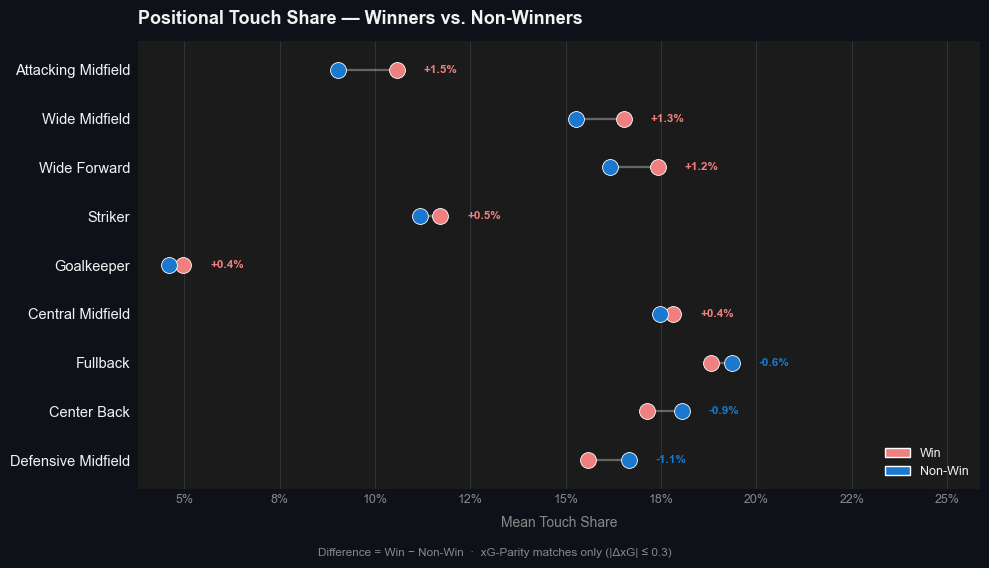

In [40]:
# ── Palette ───────────────────────────────────────────────────────────────────
BG_DARK   = "#0E1117"
BG_PANEL  = "#1B1B1B"
CORAL     = "lightcoral"
BLUE      = "#1A78CF"
WHITE     = "#F2F2F2"
GREY      = "#888888"
SPINE_COL = "#2E323A"

# ── Aggregate from touches_pd (computed in Section 2) ─────────────────────────
touch_agg = (
    team_match_position_touches
    .groupby(["position_bin", "outcome_binary"])["touch_share"]
    .mean()
    .unstack()
    .reset_index()
)
touch_agg = touch_agg.rename(columns={"Non-Win": "Non_Win"})
touch_agg["diff"] = touch_agg["Win"] - touch_agg["Non_Win"]
touch_agg = touch_agg.sort_values("diff", ascending=True)

positions = touch_agg["position_bin"].tolist()
n = len(positions)

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

all_x = list(touch_agg["Win"]) + list(touch_agg["Non_Win"])
ax.set_xlim(min(all_x) - 0.008, max(all_x) + 0.065)

ax.grid(axis="x", color=SPINE_COL, lw=0.7, zorder=0)
ax.grid(axis="y", visible=False)
for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COL)

for i, row in enumerate(touch_agg.itertuples()):
    bw, bn, diff = row.Win, row.Non_Win, row.diff
    ax.plot([bw, bn], [i, i], color=WHITE, lw=1.6, alpha=0.35, zorder=2)
    ax.scatter(bw, i, color=CORAL, s=130, zorder=4, edgecolors="white", linewidths=0.6)
    ax.scatter(bn, i, color=BLUE,  s=130, zorder=4, edgecolors="white", linewidths=0.6)
    sign  = "+" if diff >= 0 else ""
    label = f"{sign}{diff*100:.1f}%"
    col   = CORAL if diff > 0 else (BLUE if diff < 0 else GREY)
    ax.text(max(bw, bn) + 0.007, i, label,
            va="center", ha="left", fontsize=8.5,
            color=col, fontweight="bold", zorder=5)

ax.set_yticks(range(n))
ax.set_yticklabels(positions, color=WHITE, fontsize=10.5)
ax.set_ylim(-0.6, n - 0.4)
ax.tick_params(axis="y", length=0, pad=6)
ax.tick_params(axis="x", colors=GREY, labelsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Mean Touch Share", color=GREY, fontsize=10, labelpad=7)

ax.set_title(
    "Positional Touch Share — Winners vs. Non-Winners",
    color=WHITE, fontsize=13, fontweight="bold", loc="left", pad=12,
)
fig.text(0.5, -0.02,
    "Difference = Win − Non-Win  ·  xG-Parity matches only (|ΔxG| ≤ 0.3)",
    ha="center", color=GREY, fontsize=8.5)

legend_handles = [
    mpatches.Patch(facecolor=CORAL, edgecolor="white", label="Win"),
    mpatches.Patch(facecolor=BLUE,  edgecolor="white", label="Non-Win"),
]
ax.legend(handles=legend_handles, loc="lower right",
          framealpha=0.15, facecolor=BG_PANEL,
          labelcolor=WHITE, fontsize=9, edgecolor=SPINE_COL)

plt.tight_layout()
plt.show()

## Visualization 2: Progressive Carry Distance — Winners vs. Non-Winners

**What this shows:** Mean progressive carry distance by position for winning and 
non-winning teams, displayed as a diverging bar chart ordered by difference.

**Finding it supports:** Section 3A — winners carry more aggressively in attacking positions.

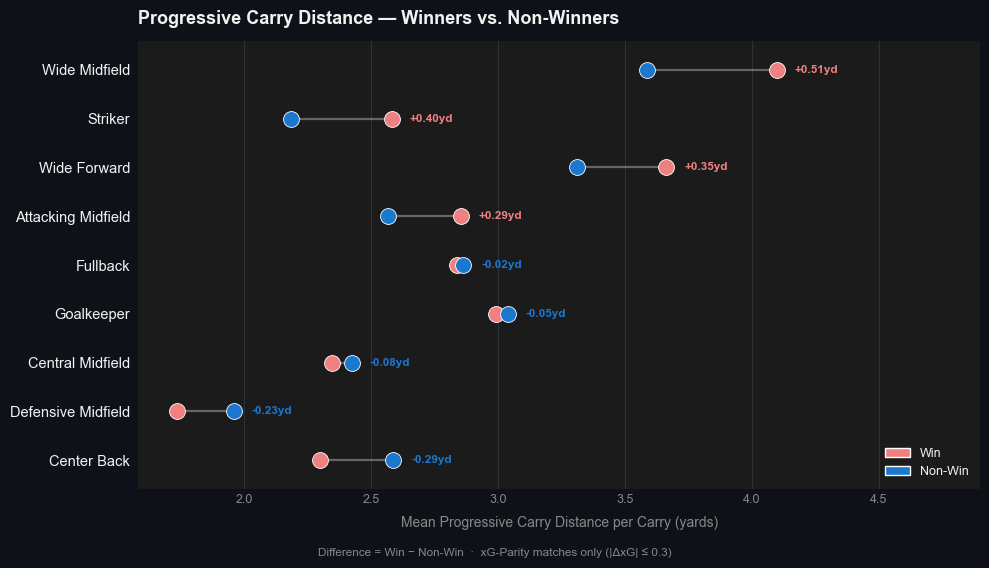

In [41]:
# ── Palette ───────────────────────────────────────────────────────────────────
BG_DARK   = "#0E1117"
BG_PANEL  = "#1B1B1B"
CORAL     = "lightcoral"
BLUE      = "#1A78CF"
WHITE     = "#F2F2F2"
GREY      = "#888888"
SPINE_COL = "#2E323A"

# ── Aggregate from carries_pd (computed in Section 3) ─────────────────────────
# carries_pd has: match_id, team, position_bin, mean_prog_distance, outcome, outcome_binary
dist_agg = (
    carries_pd
    .groupby(["position_bin", "outcome_binary"])["mean_prog_distance"]
    .mean()
    .unstack()
    .reset_index()
)
dist_agg = dist_agg.rename(columns={"Non-Win": "Non_Win"})
dist_agg["diff"] = dist_agg["Win"] - dist_agg["Non_Win"]
dist_agg = dist_agg.sort_values("diff", ascending=True)

positions = dist_agg["position_bin"].tolist()
n = len(positions)

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

all_x = list(dist_agg["Win"]) + list(dist_agg["Non_Win"])
ax.set_xlim(min(all_x) - 0.15, max(all_x) + 0.8)

ax.grid(axis="x", color=SPINE_COL, lw=0.7, zorder=0)
ax.grid(axis="y", visible=False)
for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COL)

for i, row in enumerate(dist_agg.itertuples()):
    bw, bn, diff = row.Win, row.Non_Win, row.diff
    ax.plot([bw, bn], [i, i], color=WHITE, lw=1.6, alpha=0.35, zorder=2)
    ax.scatter(bw, i, color=CORAL, s=130, zorder=4, edgecolors="white", linewidths=0.6)
    ax.scatter(bn, i, color=BLUE,  s=130, zorder=4, edgecolors="white", linewidths=0.6)
    sign  = "+" if diff >= 0 else ""
    label = f"{sign}{diff:.2f}yd"
    col   = CORAL if diff > 0 else (BLUE if diff < 0 else GREY)
    ax.text(max(bw, bn) + 0.07, i, label,
            va="center", ha="left", fontsize=8.5,
            color=col, fontweight="bold", zorder=5)

ax.set_yticks(range(n))
ax.set_yticklabels(positions, color=WHITE, fontsize=10.5)
ax.set_ylim(-0.6, n - 0.4)
ax.tick_params(axis="y", length=0, pad=6)
ax.tick_params(axis="x", colors=GREY, labelsize=9)
ax.set_xlabel("Mean Progressive Carry Distance per Carry (yards)", color=GREY, fontsize=10, labelpad=7)

ax.set_title(
    "Progressive Carry Distance — Winners vs. Non-Winners",
    color=WHITE, fontsize=13, fontweight="bold", loc="left", pad=12,
)
fig.text(0.5, -0.02,
    "Difference = Win − Non-Win  ·  xG-Parity matches only (|ΔxG| ≤ 0.3)",
    ha="center", color=GREY, fontsize=8.5)

legend_handles = [
    mpatches.Patch(facecolor=CORAL, edgecolor="white", label="Win"),
    mpatches.Patch(facecolor=BLUE,  edgecolor="white", label="Non-Win"),
]
ax.legend(handles=legend_handles, loc="lower right",
          framealpha=0.15, facecolor=BG_PANEL,
          labelcolor=WHITE, fontsize=9, edgecolor=SPINE_COL)

plt.tight_layout()
plt.show()

## Visualization 3: Touch Share vs. Progressive Distance — Independence Plot

**What this shows:** Scatter plot of mean touch share vs. mean progressive distance 
by position, with Win and Non-Win shown as separate series.

**Finding it supports:** Section 3B — the two dimensions are independent (Spearman r ≈ 0),
visible as no clear linear relationship across positions.

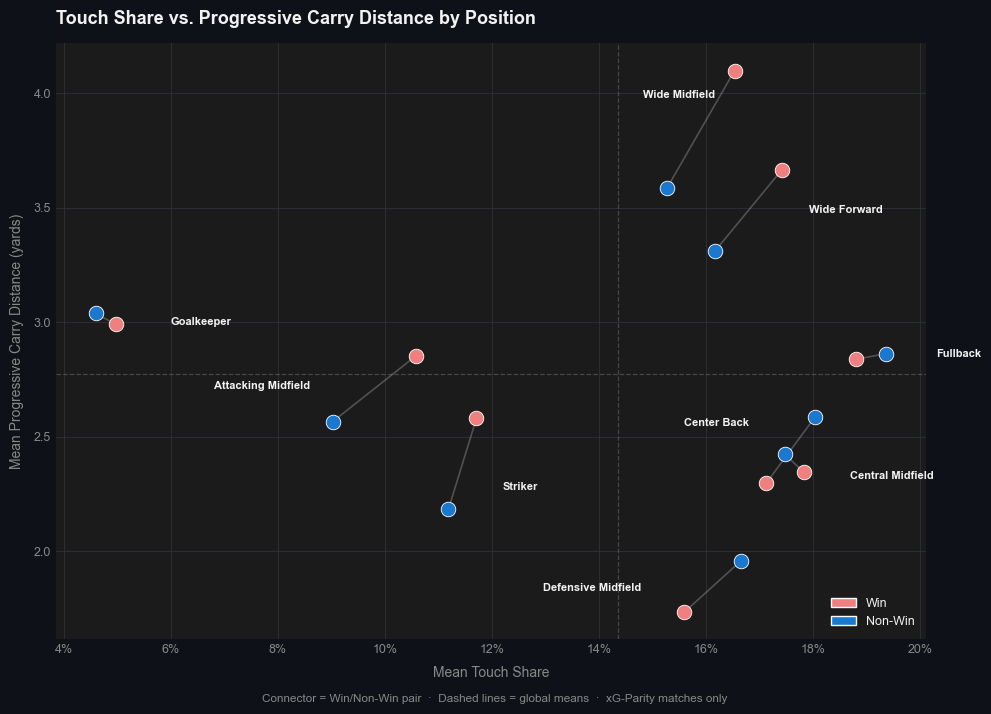

In [42]:
# ── Palette ───────────────────────────────────────────────────────────────────
BG_DARK   = "#0E1117"
BG_PANEL  = "#1B1B1B"
CORAL     = "lightcoral"
BLUE      = "#1A78CF"
WHITE     = "#F2F2F2"
GREY      = "#888888"
SPINE_COL = "#2E323A"

# ── Aggregate ─────────────────────────────────────────────────────────────────
touch_agg = (
    team_match_position_touches
    .groupby(["position_bin", "outcome_binary"])["touch_share"]
    .mean()
    .reset_index()
)

prog_agg = (
    carries_pd
    .groupby(["position_bin", "outcome_binary"])["mean_prog_distance"]
    .mean()
    .reset_index()
)

scatter_df = touch_agg.merge(
    prog_agg,
    on=["position_bin", "outcome_binary"],
    how="inner"
)

# Optional safety
scatter_df = scatter_df.dropna(subset=["touch_share", "mean_prog_distance"])
scatter_df = scatter_df.sort_values(["position_bin", "outcome_binary"])

# Split
wins    = scatter_df[scatter_df["outcome_binary"] == "Win"]
nonwins = scatter_df[scatter_df["outcome_binary"] == "Non-Win"]

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

# Grid + spines
ax.grid(axis="x", color=SPINE_COL, lw=0.6, zorder=0)
ax.grid(axis="y", color=SPINE_COL, lw=0.6, zorder=0)
for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COL)

# Mean lines
ax.axvline(scatter_df["touch_share"].mean(), color=GREY, lw=0.9, ls="--", alpha=0.4, zorder=1)
ax.axhline(scatter_df["mean_prog_distance"].mean(), color=GREY, lw=0.9, ls="--", alpha=0.4, zorder=1)

# ── Labels config ─────────────────────────────────────────────────────────────
label_cfg = {
    "Goalkeeper":          (0.060, 3.00, "left",   "center"),
    "Wide Midfield":       (0.155, 3.97, "center", "bottom"),
    "Wide Forward":        (0.193, 3.49, "right",  "center"),
    "Fullback":            (0.203, 2.86, "left",   "center"),
    "Attacking Midfield":  (0.086, 2.72, "right",  "center"),
    "Center Back":         (0.168, 2.56, "right",  "center"),
    "Central Midfield":    (0.187, 2.33, "left",   "center"),
    "Striker":             (0.122, 2.28, "left",   "center"),
    "Defensive Midfield":  (0.148, 1.84, "right",  "center"),
}

positions = sorted(scatter_df["position_bin"].unique())

# ── Plot per position ─────────────────────────────────────────────────────────
for pos in positions:
    grp = scatter_df[scatter_df["position_bin"] == pos]
    w_row = grp[grp["outcome_binary"] == "Win"]
    n_row = grp[grp["outcome_binary"] == "Non-Win"]

    if w_row.empty or n_row.empty:
        continue

    # FIXED extraction (this was your bug)
    wx = w_row["touch_share"].iloc[0]
    wy = w_row["mean_prog_distance"].iloc[0]
    nx = n_row["touch_share"].iloc[0]
    ny = n_row["mean_prog_distance"].iloc[0]

    cx, cy = (wx + nx) / 2, (wy + ny) / 2

    # connector line
    ax.plot([wx, nx], [wy, ny], color=WHITE, lw=1.2, alpha=0.25, zorder=2)

    # points
    ax.scatter(wx, wy, color=CORAL, s=110, zorder=5, edgecolors="white", linewidths=0.6)
    ax.scatter(nx, ny, color=BLUE,  s=110, zorder=5, edgecolors="white", linewidths=0.6)

    # labels
    lx, ly, ha, va = label_cfg.get(pos, (cx, cy + 0.1, "center", "bottom"))
    ax.text(lx, ly, pos, ha=ha, va=va,
            color=WHITE, fontsize=8, fontweight="bold", zorder=6)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.tick_params(axis="x", colors=GREY, labelsize=9)
ax.tick_params(axis="y", colors=GREY, labelsize=9)

ax.set_xlabel("Mean Touch Share", color=GREY, fontsize=10, labelpad=7)
ax.set_ylabel("Mean Progressive Carry Distance (yards)", color=GREY, fontsize=10, labelpad=7)

# Title
ax.set_title(
    "Touch Share vs. Progressive Carry Distance by Position",
    color=WHITE, fontsize=13, fontweight="bold", loc="left", pad=14,
)

# Subtitle
fig.text(
    0.5, -0.01,
    "Connector = Win/Non-Win pair  ·  Dashed lines = global means  ·  xG-Parity matches only",
    ha="center", color=GREY, fontsize=8.5
)

# Legend
legend_handles = [
    mpatches.Patch(facecolor=CORAL, edgecolor="white", label="Win"),
    mpatches.Patch(facecolor=BLUE,  edgecolor="white", label="Non-Win"),
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    framealpha=0.15,
    facecolor=BG_PANEL,
    labelcolor=WHITE,
    fontsize=9,
    edgecolor=SPINE_COL
)

plt.tight_layout()
plt.show()

---

# Translating Positional Structure into a Predictive Signal

The previous sections demonstrate that positional structure and ball progression exhibit measurable—though modest—differences between winning and non-winning teams in xG-parity matches.

We now translate these insights into a single composite signal, designed to capture whether a team’s positional profile is associated with winning outcomes.

This step moves from descriptive analysis to predictive modeling, allowing us to evaluate the practical utility of positional features.

## Question 6: Do the positional patterns we identified actually correlate with winning?

**Context:** Previous sections established that winners differ from non-winners in positional 
touch share and progressive carry distance. But statistical significance alone doesn't tell 
us whether these differences have practical predictive value. Here we construct a simple 
Forward Possession Index (FPI), a single score that summarizes a team's positional 
structure, and test whether it separates winners from non-winners.

**Forward Possession Index (FPI):**  
FPI = (Attacking Midfield + Wide Forward touch share) − (Center Back + Defensive Midfield + Fullback touch share)

A positive FPI means a team concentrates possession in advanced positions relative to 
defensive ones. We use only the 5 outfield positions that survived Bonferroni correction 
in Section 2. Goalkeeper touch share, while statistically significant, is excluded here 
to keep the index focused on outfield tactical structure.

**Tests:**
- Mann-Whitney U: Is FPI higher for winners than non-winners?
- AUC: How well does FPI alone discriminate between winners and non-winners?

---

We construct our predictive signal, Field Position Index (FPI), using positional touch share features identified in earlier analysis, including:
- Defensive touch share
- Midfield touch share
- Attacking touch share

These features are selected based on their statistical significance and interpretability in representing team structure.

FPI is a composite metric constructed by combining normalized positional features across defensive, midfield, and attacking units. Each component is equally weighted. Rather than examining positions individually, FPI asks whether the *overall* positional profile of a team (how much more they possess in advanced versus defensive areas) carries predictive signal for match outcomes.

We construct FPI by combining the five outfield positions 
that survived Bonferroni correction in Section 2 into a single score. The AUC (Area Under the ROC Curve) measures this directly: 
a value of 0.5 means the index is no better than a coin flip, while 1.0 means perfect 
discrimination. We are not building a model, rather we are testing whether the pattern we 
identified statistically translates into a meaningful signal in practice.

In [43]:
keep_only_dataframes(
    ['matches', 'events', 'lineups', 'team_match', 'match', 'team_outcomes', 'team_match_xg', 'match_xg', 'progressive_actions', 'team_match_position_touches',
     'carries_pd']
)

Kept DataFrames:
matches: (3464, 36)
events: (12188949, 112)
lineups: (165820, 17)
team_match_xg: (1302, 9)
team_outcomes: (6928, 4)
team_match: (6921, 9)
match: (3464, 9)
match_xg: (651, 9)
team_match_position_touches: (9207, 8)
progressive_actions: (289731, 115)
carries_pd: (9196, 7)


In [44]:
# Pivot touch share to wide format for FPI calculation
touch_wide = (
    team_match_position_touches
    .pivot_table(
        index=['match_id', 'team', 'outcome_binary'],
        columns='position_bin',
        values='touch_share',
        aggfunc='mean'
    )
    .reset_index()
)

# Compute Forward Possession Index (FPI)
attacking = ['Attacking Midfield', 'Wide Forward']
defensive = ['Center Back', 'Defensive Midfield', 'Fullback']

touch_wide['FPI'] = (
    touch_wide[attacking].sum(axis=1) -
    touch_wide[defensive].sum(axis=1)
)

# Mann-Whitney U test on FPI
win_fpi = touch_wide[touch_wide['outcome_binary'] == 'Win']['FPI']
nonwin_fpi = touch_wide[touch_wide['outcome_binary'] == 'Non-Win']['FPI']

u_stat, p_val = mannwhitneyu(win_fpi, nonwin_fpi, alternative='two-sided')
d = cohens_d(win_fpi, nonwin_fpi)

# AUC
y_true = (touch_wide['outcome_binary'] == 'Win').astype(int)
auc = roc_auc_score(y_true, touch_wide['FPI'])

print("Forward Possession Index (FPI) Analysis")
print("=" * 50)
print(f"  Win mean FPI    : {win_fpi.mean():.4f}")
print(f"  Non-Win mean FPI: {nonwin_fpi.mean():.4f}")
print(f"  Difference      : {win_fpi.mean() - nonwin_fpi.mean():.4f}")
print(f"\nMann-Whitney U Test:")
print(f"  U statistic : {u_stat:.1f}")
print(f"  p-value     : {p_val:.4f}")
print(f"  Cohen's d   : {d:.4f}")
print(f"\nPredictive Signal:")
print(f"  AUC         : {auc:.4f}")
print(f"  Interpretation: {'Better than random' if auc > 0.5 else 'No predictive signal'}")

Forward Possession Index (FPI) Analysis
  Win mean FPI    : -0.3418
  Non-Win mean FPI: -0.3753
  Difference      : 0.0334

Mann-Whitney U Test:
  U statistic : 215347.0
  p-value     : 0.0006
  Cohen's d   : 0.2140

Predictive Signal:
  AUC         : 0.5577
  Interpretation: Better than random


The model achieves an AUC of 0.558. While above random baseline (0.5), this indicates only modest predictive power, suggesting positional structure contributes signal but is not sufficient alone to predict outcomes.

### Finding 5: Forward Possession Index Confirms Positional Structure as a Real But Modest Signal

**Statistical Evidence:**
- Mann-Whitney U: U = 215,347, p = 0.0006
- Cohen's d = 0.21 (small effect)
- AUC = 0.558

**Interpretation:**  
The Forward Possession Index, combining the five outfield positions that survived 
Bonferroni correction, is significantly higher for winners than non-winners (p = 0.0006). 
Winners concentrate a greater share of touches in advanced positions relative to defensive 
ones, and this aggregate signal is robust across 1,302 team-match observations.

The AUC of 0.558 deserves careful interpretation. FPI correctly ranks a winner above a 
non-winner approximately 56% of the time, meaningfully better than chance (50%), but 
far from a standalone predictor. This is expected: soccer outcomes in xG-parity matches 
are inherently uncertain, and positional structure is one signal among many. A coin flip 
would be right 50% of the time; FPI moves that needle to 56%.

This finding motivates rather than resolves the analytical question. Positional structure 
carries real signal, enough to justify deeper investigation through tactical archetype 
clustering and multi-dimensional modeling in future work.

**Note on FPI means:** Both Win and Non-Win FPI values are negative (-0.34 and -0.38 
respectively), reflecting that all teams accumulate more touches in defensive and midfield 
positions than attacking ones by virtue of squad composition. The signal lies in the 
*difference* between groups, not the absolute values.

**Decision:** Positional structure confirmed as a modest but real predictive signal. This reinforces the idea that match outcomes are multifactorial, with positional structure acting as one contributing component alongside chance quality and contextual factors.

---

---

# Translating Tactical Patterns into Team-Level Signals

The previous sections show that positional structure and progression patterns exhibit measurable—though sometimes limited—differences between winning and non-winning teams in xG-parity matches.

Rather than evaluating these effects at the positional or event level, we now aggregate them into team-level metrics that summarize how teams structure and progress play within a match.

This step shifts the analysis from isolated patterns to broader tactical profiles, allowing us to assess whether higher-level summaries provide clearer separation between winning and non-winning teams.

## Question 6: Do team-level tactical profiles differentiate winning from non-winning teams?

**Context:** Earlier sections identified differences in where teams possess the ball, which positions drive progression, and how forward movement behaves. However, these insights are distributed across multiple dimensions and may not translate directly into a unified signal. Here, we construct team-level metrics that capture key aspects of tactical behavior and evaluate whether they distinguish outcomes more clearly.

**Team-Level Metrics:**
- Wide progression share — proportion of progression occurring in wide areas  
- Build-up share — proportion of touches in defensive and build-up positions  
- Progression concentration — maximum share of progression contributed by a single position  
- Central midfield control — share of touches concentrated in central midfield roles  

**Tests:**
- Mann-Whitney U: Do these metrics differ between winners and non-winners?
- Distribution comparison: Do winners exhibit distinct tactical profiles?

---

In [45]:
keep_only_dataframes(
    ['matches', 'events', 'lineups', 'team_match', 'match', 'team_outcomes', 'team_match_xg', 'match_xg', 'progressive_actions', 'team_match_position_touches',
     'carries_pd']
)

Kept DataFrames:
matches: (3464, 36)
events: (12188949, 112)
lineups: (165820, 17)
team_match_xg: (1302, 9)
team_outcomes: (6928, 4)
team_match: (6921, 9)
match: (3464, 9)
match_xg: (651, 9)
team_match_position_touches: (9207, 8)
progressive_actions: (289731, 115)
carries_pd: (9196, 7)


In [46]:
# Base
team_level = team_match_xg[["match_id", "team", "outcome"]].copy()

# ------------------------------------------------------------------
# 6) Wide progression share
# ------------------------------------------------------------------

progressive_events = events[events["match_id"].isin(team_match_xg["match_id"])].copy()

prog_events = progressive_events[progressive_events["type"].isin(["Pass", "Carry"])].copy()

prog_events["is_progressive"] = (
    ((prog_events["type"] == "Pass") &
     (prog_events["pass_end_location_x"] - prog_events["location_x"] >= 10)) |
    ((prog_events["type"] == "Carry") &
     (prog_events["carry_end_location_x"] - prog_events["location_x"] >= 10))
)

progressive_actions = prog_events[prog_events["is_progressive"]].copy()

def classify_zone(y):
    return "Wide" if (y < 20 or y > 60) else "Central"

progressive_actions["zone"] = progressive_actions["location_y"].apply(classify_zone)

team_prog_total = (
    progressive_actions
    .groupby(["match_id", "team"])
    .size()
    .reset_index(name="team_progressive_actions")
)

team_wide_prog = (
    progressive_actions[progressive_actions["zone"] == "Wide"]
    .groupby(["match_id", "team"])
    .size()
    .reset_index(name="wide_progressive_actions")
)

team_width = team_prog_total.merge(
    team_wide_prog,
    on=["match_id", "team"],
    how="left"
)

team_width["wide_progressive_actions"] = team_width["wide_progressive_actions"].fillna(0)

team_width["wide_progression_share"] = (
    team_width["wide_progressive_actions"] /
    team_width["team_progressive_actions"]
)

team_level = team_level.merge(
    team_width[["match_id", "team", "wide_progression_share"]],
    on=["match_id", "team"],
    how="left"
)

# ------------------------------------------------------------------
# 7) Build-up share
# ------------------------------------------------------------------

TOUCH_EVENTS = ["Ball Receipt*", "Pass", "Carry", "Dribble", "Shot"]

touches = events[
    (events["match_id"].isin(team_match_xg["match_id"])) &
    (events["type"].isin(TOUCH_EVENTS))
].copy()

touches["position_bin"] = touches["position"].map(POSITION_BIN_MAP)
touches = touches.dropna(subset=["position_bin"])

team_pos_touches = (
    touches
    .groupby(["match_id", "team", "position_bin"])
    .size()
    .reset_index(name="touches")
)

BUILD_UP = ["Center Back", "Fullback", "Defensive Midfield"]

team_pos_touches["phase"] = np.where(
    team_pos_touches["position_bin"].isin(BUILD_UP),
    "BuildUp",
    "Advanced"
)

team_phase = (
    team_pos_touches
    .groupby(["match_id", "team", "phase"])["touches"]
    .sum()
    .reset_index()
)

team_phase = (
    team_phase
    .pivot_table(
        index=["match_id", "team"],
        columns="phase",
        values="touches",
        fill_value=0
    )
    .reset_index()
)

team_phase["build_up_share"] = (
    team_phase["BuildUp"] /
    (team_phase["BuildUp"] + team_phase["Advanced"])
)

team_level = team_level.merge(
    team_phase[["match_id", "team", "build_up_share"]],
    on=["match_id", "team"],
    how="left"
)

# ------------------------------------------------------------------
# 8) Progression concentration
# ------------------------------------------------------------------

progressive_actions["position_bin"] = progressive_actions["position"].map(POSITION_BIN_MAP)
progressive_actions = progressive_actions.dropna(subset=["position_bin"])

team_match_position_progressions = (
    progressive_actions
    .groupby(["match_id", "team", "position_bin"])
    .size()
    .reset_index(name="progressive_actions")
)

team_match_progression_totals = (
    team_match_position_progressions
    .groupby(["match_id", "team"])["progressive_actions"]
    .sum()
    .reset_index(name="team_progressive_actions")
)

team_match_position_progressions = team_match_position_progressions.merge(
    team_match_progression_totals,
    on=["match_id", "team"],
    how="left"
)

team_match_position_progressions["progressive_share"] = (
    team_match_position_progressions["progressive_actions"] /
    team_match_position_progressions["team_progressive_actions"]
)

max_prog = (
    team_match_position_progressions
    .groupby(["match_id", "team"])["progressive_share"]
    .max()
    .reset_index(name="max_progression_share")
)

team_level = team_level.merge(
    max_prog,
    on=["match_id", "team"],
    how="left"
)

# ------------------------------------------------------------------
# 9) Central midfield control
# ------------------------------------------------------------------

MIDFIELD = ["Central Midfield", "Attacking Midfield"]

midfield = touches[
    touches["position_bin"].isin(MIDFIELD)
]

midfield_counts = (
    midfield
    .groupby(["match_id", "team"])
    .size()
    .reset_index(name="midfield_touches")
)

team_total_touches = (
    touches
    .groupby(["match_id", "team"])
    .size()
    .reset_index(name="team_touches")
)

midfield_share = midfield_counts.merge(
    team_total_touches,
    on=["match_id", "team"],
    how="left"
)

midfield_share["central_midfield_touch_share"] = (
    midfield_share["midfield_touches"] /
    midfield_share["team_touches"]
)

team_level = team_level.merge(
    midfield_share[["match_id", "team", "central_midfield_touch_share"]],
    on=["match_id", "team"],
    how="left"
)

# ------------------------------------------------------------------
# Final
# ------------------------------------------------------------------

team_level = team_level.sort_values(["match_id", "team"]).reset_index(drop=True)

team_level["outcome_binary"] = np.where(
    team_level["outcome"] == "Win",
    "Win",
    "Non-Win"
)

display(team_level.head(2))
print(team_level.shape)

,match_id,team,outcome,wide_progression_share,build_up_share,max_progression_share,central_midfield_touch_share,outcome_binary
0,7480,OL Reign,Win,0.491228,0.397227,0.267544,0.291191,Win
1,7480,Utah Royals,Loss,0.429204,0.605430,0.278761,0.128507,Non-Win


(1302, 8)


In [47]:
metrics = [
    "wide_progression_share",
    "build_up_share",
    "max_progression_share",
    "central_midfield_touch_share"
]

print("Team-Level Statistical Tests (Win vs Non-Win)")
print("=" * 60)

for col in metrics:
    win = team_level[team_level["outcome_binary"] == "Win"][col].dropna()
    nonwin = team_level[team_level["outcome_binary"] == "Non-Win"][col].dropna()
    
    if len(win) == 0 or len(nonwin) == 0:
        print(f"{col}: insufficient data")
        continue
    
    stat, p = mannwhitneyu(win, nonwin, alternative="two-sided")
    
    print(f"{col}: p-value = {p:.4f}")

Team-Level Statistical Tests (Win vs Non-Win)
wide_progression_share: p-value = 0.2828
build_up_share: p-value = 0.0000
max_progression_share: p-value = 0.0008
central_midfield_touch_share: p-value = 0.0059


### Finding 6: Team-Level Tactical Profiles Provide Clearer Separation

**6A — Team-Level Metrics (Win vs. Non-Win):**

| Metric | p-value | Significance |
|--------|--------|--------------|
| Wide progression share | 0.2828 | Not significant |
| Build-up share | 0.0000 | Significant |
| Max progression share | 0.0008 | Significant |
| Central midfield touch share | 0.0059 | Significant |

**Interpretation:**  
At the team level, certain tactical dimensions show clear separation between winning and non-winning teams, while others do not. In particular, build-up share and progression concentration (max progression share) are strongly associated with outcomes, suggesting that how teams structure possession and concentrate progression plays a meaningful role in differentiating results.

Central midfield control also shows a statistically significant difference, indicating that involvement of central roles may contribute to successful outcomes. In contrast, wide progression share does not differ significantly between groups, reinforcing earlier findings that spatial distribution (wide vs central) is not a primary driver of results.

Taken together, these results suggest that higher-level summaries of team behavior—particularly those capturing structure and concentration—provide clearer and more consistent signals than isolated positional or spatial metrics.

**Decision:** Team-level metrics related to structure and concentration show statistically significant differences between winners and non-winners, while spatial progression patterns do not.

---

## Visualization 4: Build-Up Share vs. Progression Concentration — Team Level

**What this shows:** Scatter plot of team-level mean build-up share (center backs, fullbacks, and defensive midfielders) against mean progression concentration (maximum single-position progressive action share), split by match outcome. Barcelona is highlighted as a case study team.

**Finding it supports:** Finding 6A — both build-up share (*p* = 0.0000) and max progression share (*p* = 0.0008) are statistically significant predictors of match outcome, with Barcelona's Win and Non-Win clusters illustrating how these two dimensions shift together depending on result.

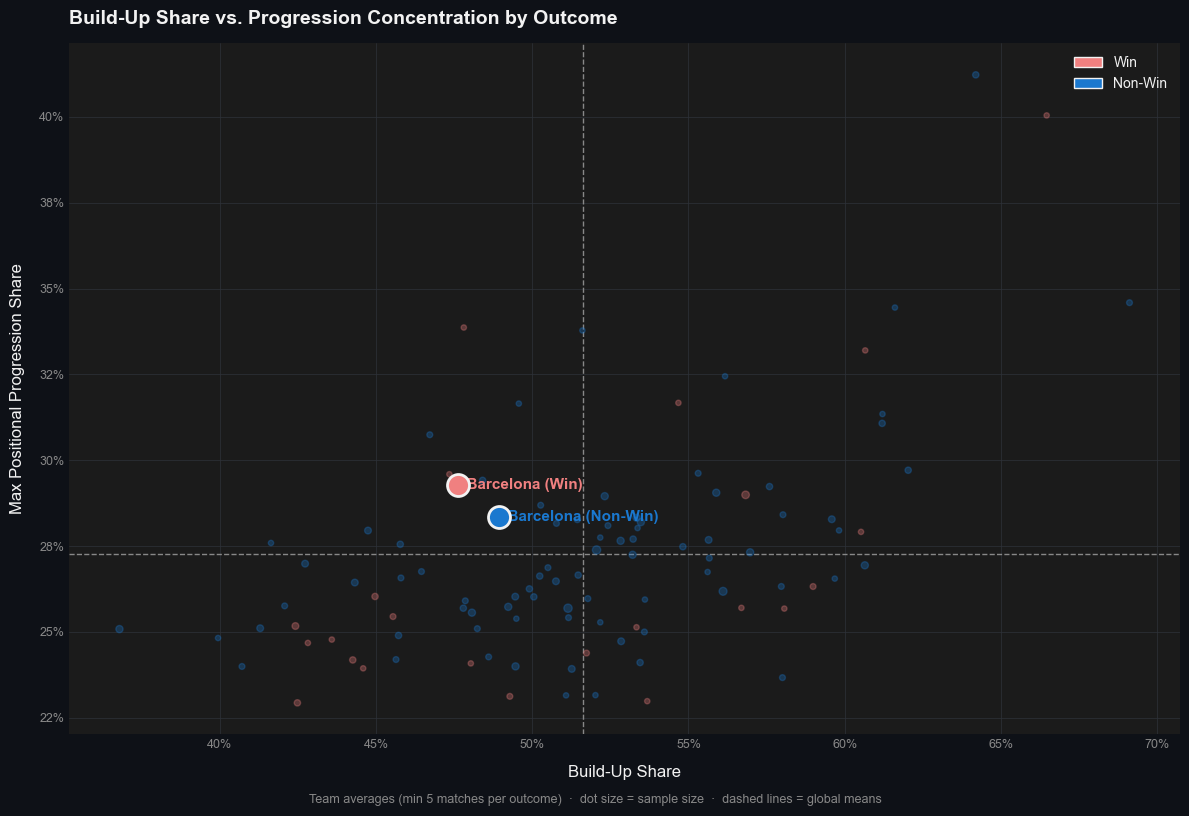

In [63]:
# ── 6B: Scatter — Build-Up Share × Progression Concentration (Team Level) ──────

HIGHLIGHT = "Barcelona"

team_agg = (
    team_level
    .groupby(["team", "outcome_binary"])
    .agg(
        build_up_share=("build_up_share", "mean"),
        max_progression_share=("max_progression_share", "mean"),
        n=("match_id", "count"),
    )
    .reset_index()
)
team_agg = team_agg[team_agg["n"] >= 5]

win_df    = team_agg[team_agg["outcome_binary"] == "Win"]
nonwin_df = team_agg[team_agg["outcome_binary"] == "Non-Win"]

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

# Background teams
ax.scatter(
    nonwin_df[nonwin_df["team"] != HIGHLIGHT]["build_up_share"],
    nonwin_df[nonwin_df["team"] != HIGHLIGHT]["max_progression_share"],
    c=BLUE, alpha=0.3,
    s=nonwin_df[nonwin_df["team"] != HIGHLIGHT]["n"] * 3,
    zorder=2,
)
ax.scatter(
    win_df[win_df["team"] != HIGHLIGHT]["build_up_share"],
    win_df[win_df["team"] != HIGHLIGHT]["max_progression_share"],
    c=CORAL, alpha=0.3,
    s=win_df[win_df["team"] != HIGHLIGHT]["n"] * 3,
    zorder=2,
)

# Barcelona — solid with white edge
barca_nw = nonwin_df[nonwin_df["team"] == HIGHLIGHT]
barca_w  = win_df[win_df["team"] == HIGHLIGHT]

ax.scatter(
    barca_nw["build_up_share"], barca_nw["max_progression_share"],
    c=BLUE, s=250, zorder=5, edgecolors=WHITE, linewidths=2,
)
ax.scatter(
    barca_w["build_up_share"], barca_w["max_progression_share"],
    c=CORAL, s=250, zorder=5, edgecolors=WHITE, linewidths=2,
)

for _, row in barca_w.iterrows():
    ax.annotate(
        "  Barcelona (Win)",
        (row["build_up_share"], row["max_progression_share"]),
        color=CORAL, fontsize=11, va="center", fontweight="bold",
    )
for _, row in barca_nw.iterrows():
    ax.annotate(
        "  Barcelona (Non-Win)",
        (row["build_up_share"], row["max_progression_share"]),
        color=BLUE, fontsize=11, va="center", fontweight="bold",
    )

# Reference lines at global means
ax.axvline(team_agg["build_up_share"].mean(), color=GREY, lw=1, ls="--", zorder=1)
ax.axhline(team_agg["max_progression_share"].mean(), color=GREY, lw=1, ls="--", zorder=1)

# Axes
ax.set_xlabel("Build-Up Share", color=WHITE, fontsize=12, labelpad=10)
ax.set_ylabel("Max Positional Progression Share", color=WHITE, fontsize=12, labelpad=10)
ax.tick_params(colors=GREY, labelsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COL)
ax.grid(axis="both", color=SPINE_COL, lw=0.5, zorder=0)

ax.set_title(
    "Build-Up Share vs. Progression Concentration by Outcome",
    color=WHITE, fontsize=14, fontweight="bold", pad=14, loc="left",
)
fig.text(
    0.5, -0.01,
    "Team averages (min 5 matches per outcome)  ·  dot size = sample size  ·  dashed lines = global means",
    ha="center", color=GREY, fontsize=9,
)

legend_handles = [
    mpatches.Patch(facecolor=CORAL, edgecolor=WHITE, label="Win"),
    mpatches.Patch(facecolor=BLUE,  edgecolor=WHITE, label="Non-Win"),
]
ax.legend(handles=legend_handles, facecolor=BG_PANEL, edgecolor=SPINE_COL, labelcolor=WHITE, fontsize=10)

plt.tight_layout()
plt.show()

---

# Conclusions and Implications

## What We Set Out to Answer

In matches where both teams create nearly equal expected goals, what separates winners 
from non-winners? xG alone cannot answer this question because, by construction, xG-parity 
matches remove clear differences in chance quality. We hypothesized that **tactical structure** 
— how teams distribute possession and progress the ball — might provide the signal that xG cannot.

---

## What We Found

Across positional, event-level, and team-level analyses applied to 651 xG-parity matches 
(1,302 team-match observations), we find that not all tactical dimensions are equally informative.

| Section | Question | Method | Result | Interpretation |
|---------|----------|--------|--------|----------------|
| 1 | Are parity matches genuinely close? | Chi-square | p < 0.0001 | Higher draw rate confirms balance |
| 2 | Do winners differ positionally? | Mann-Whitney U + Bonferroni | 6/9 positions significant | Winners shift possession forward |
| 3 | How do teams progress the ball? | Share + distance + correlation | Mixed | Progression differs but is independent of structure |
| 4 | Does structure predict wins? | Mann-Whitney + AUC | AUC ≈ 0.56 | Weak but real predictive signal |
| 5 | Does spatial progression matter? | Mann-Whitney U | p ≈ 0.95 | No meaningful difference |
| 6 | Do team-level metrics differentiate outcomes? | Mann-Whitney U | Mixed | Structure & concentration matter most |

---

## The Answer

When xG is equal, **tactical structure — but not all aspects of it — separates winners from non-winners**.

Three key insights emerge:

1. **Where teams operate matters**  
   Winners consistently allocate more possession to advanced roles and less to defensive ones.  
   This forward shift in positional structure is robust across multiple tests.

2. **How teams progress matters — but independently**  
   Teams differ in how aggressively positions move the ball forward, and this behavior is largely 
   independent of where possession occurs. Structure and progression represent two distinct 
   tactical dimensions.

3. **Team-level structure sharpens the signal**  
   When aggregated to the team level, the clearest differentiators are:
   - **Build-up share** — how much play occurs in defensive vs advanced phases  
   - **Progression concentration** — whether progression is distributed or concentrated in key roles  

   In contrast, **spatial distribution (wide vs central progression) shows no meaningful effect**, 
   indicating that *where on the pitch* progression occurs is less important than *who drives it* 
   and *how it is structured*.

---

## Limitations

- **Dataset scope:** StatsBomb open data covers a subset of competitions and seasons, 
  primarily at the elite level. Results may not generalize across all leagues or levels.
- **Causality:** The analysis is correlational. Observed patterns may reflect game state 
  (teams behave differently when leading) rather than purely pre-match tactical intent.
- **xG threshold choice:** The 0.3 threshold defines parity but is not uniquely optimal; 
  results may vary under alternative definitions.
- **Model simplicity:** The Forward Possession Index and team-level metrics are intentionally 
  simple summaries. More complex models incorporating interactions and temporal dynamics 
  may yield stronger predictive performance.

---

## Implications and Next Steps

This analysis shows that **not all tactical features are equally informative**. Structure and 
role-based behavior consistently matter, while spatial distribution does not. Importantly, 
aggregating to the team level produces clearer and more stable signals than isolated 
event-level metrics.

A natural next step (outside the scope of this course) is to move from individual metrics to **holistic tactical profiles**:

- **Clustering:** Identify archetypes of team behavior based on structure, progression, and concentration  
- **Archetype outcomes:** Test whether certain tactical profiles win more consistently  
- **Modeling:** Build predictive models using combined team-level features  
- **Validation:** Evaluate robustness on out-of-sample or temporal splits  

---

## Statistical Rigor Summary

This analysis applies a consistent set of non-parametric and complementary methods:

- **Mann-Whitney U:** Detect differences between winners and non-winners  
- **Effect size (directional):** Evaluate practical magnitude of differences  
- **Bonferroni correction:** Control for multiple testing in positional analysis  
- **Spearman correlation:** Assess independence between tactical dimensions  
- **AUC:** Evaluate predictive usefulness of composite signals  

The key strength lies not in any single test, but in the convergence of evidence across 
levels of analysis — positional, event-based, and team-level — each reinforcing the same 
core conclusion.

---

*This notebook serves as the analytical foundation for Team 4's Georgia Tech MSA Spring 
2026 Practicum final deliverable. Full code, data pipeline, and reproducibility 
instructions are available in the project repository.*